# CTA200H Mini-Project: MW Analogues in cosmological simulations

## 1. Retrieving EAGLE Galaxy properties: your first SQL query in Python

In [1]:
import eagleSqlTools as sql

In [2]:
username = 'fcc018'
password = 'whj96CUW'
con = sql.connect(username, password=password)

In [3]:
query="""SELECT MassType_Star as stellar_mass,
StarFormationRate as SFR
FROM RefL0100N1504_SubHalo
WHERE SnapNum = 28"""

In [4]:
data = sql.execute_query(con,query)

*What information does the query retrieve from the simulation? What condition is placed on the query, and what does that mean for the eventual output? Could you have made the same constraint using a different column in the table?*

- The query retrieves the total mass of all stars within the galaxy and their star formation rate for each of the galaxies from the 28th "Snapshot" which represents a redshift of 0 (https://arxiv.org/pdf/1510.01320).  

- The condition placed on the query is too only pull the data from the 28th snapshot, which means that the data from the simulation represents data from a redshift of 0. This means that the results will be from the simulations from the "present day".

- The same constraint can be made using the column "Redshift" and requesting only data where Redshift = 0.0.

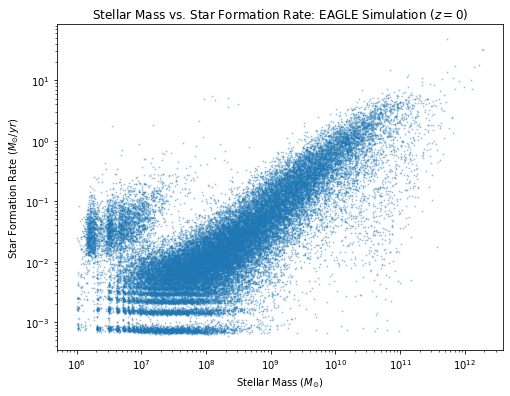

In [5]:
import matplotlib.pyplot as plt
import numpy as np

stellar_mass = data['stellar_mass']
star_formation_rate = data['SFR']
plt.figure(figsize=(8, 6))
plt.scatter(stellar_mass, star_formation_rate, s=1, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass ($M_{\odot}$)')
plt.ylabel('Star Formation Rate ($M_{\odot}/yr$)')
plt.title('Stellar Mass vs. Star Formation Rate: EAGLE Simulation ($z=0$)')
plt.savefig('eagle_sfr_vs_mass.pdf', format='pdf', bbox_inches='tight')
plt.show()

*Once you make the plot, you should notice some interesting features arising in the distribution. This figure is actually a fundamental diagnostic of galaxy formation which has had a huge number of observational studies devoted to it. Try to describe some of the features here and try to relate them to what you think this means for galaxies in the Universe (googling the term ’galaxy star formation main sequence’ will help here! This ‘astrobite’ may also be useful!). There are also a number of features of this distribution that are very different to what we see in nature. What do you think these are? Why do you think they would arise in these simulations of galaxies? As a hint: the answer to this is one of the reasons we can run simulations of large volumes of the Universe on useful timescales. Can you see anything else in this figure that is unusual?*

There is a clear correlation between Stellar Mass and the SFR, where more massive galaxies have higher SFR. There is a "floor" at lower Stellar Masses and SFRs, with small gaps in the data, creating lines. For masses less than 10^10.5 but more than 10^9.5 solar masses, AGN feedback might exhibit lower SFRs due to quenching. For galaxies with larger masses than 10^10.5 solar masses, most galaxies are most likely already quenched, causing a lack of trends (astrobites). Key differences from observations of nature include over-quenching at low masses where the simulation has a lack of data but where dwarf galaxies should still be star-forming and the "lines" rather than gradual transitions. These may arise as simulations use discrete large timesteps that skip stages lasting only a few Myrs. This computational 'shortcut' is how large cosmological volumes are simulated on practical timescales instead of tracking every stage. 

## 2. Going Deeper into the Simulations: more properties and more snapshots

*As you may have realised already, the simulation data in the database covers a number of different
‘snapshots’ of the simulation. These are a full dump of the current state of all the particles at any
time. While we are looking at the overall properties of galaxies which are derived from these particles,
these properties are computed at every snaphot as well. Above, we specified that we wanted to look
at the final output (at a redshift of 0) by specifying SnapNum = 28. However, we can change this to
look at a wider range of outputs. Try to change this so that we access all galaxies that are found in
snapshots after a redshift of 0.5 (you will need the Redshift column in the database, and remember
that ‘after’ redshift 0.5 is a range of redshifts from 0 < z < 0.5).*

In [6]:
query2="""SELECT MassType_Star as stellar_mass,
StarFormationRate as SFR
FROM RefL0100N1504_SubHalo
WHERE Redshift >=0.0 and Redshift < 0.5"""

In [7]:
data2 = sql.execute_query(con,query2)

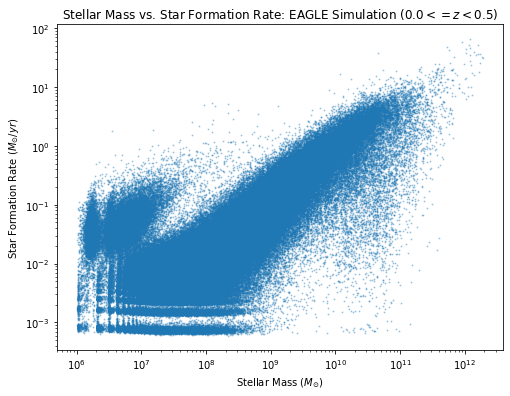

In [8]:
import matplotlib.pyplot as plt
import numpy as np

stellar_mass = data2['stellar_mass']
star_formation_rate = data2['SFR']
plt.figure(figsize=(8, 6))
plt.scatter(stellar_mass, star_formation_rate, s=1, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass ($M_{\odot}$)')
plt.ylabel('Star Formation Rate ($M_{\odot}/yr$)')
plt.title('Stellar Mass vs. Star Formation Rate: EAGLE Simulation ($0.0<=z<0.5$)')
plt.savefig('eagle2_sfr_vs_mass.pdf', format='pdf', bbox_inches='tight')
plt.show()

*Can you compare the number of 2 galaxies between this output and that from Section 1? Write down 2 changes in the distributions when you remake the figure.*

There is a significantly larger amount of galaxies in this output compared to the first section (10x) and the Main Sequence is denser. Two changes in distributions include the Main Sequence being denser and broader, with more scattering vertically on the edges of the sequence compared to the first sequence, and the Main Sequence being shifted upwards, with more galaxies with high SFRs and Stellar Masses compared to the first section.

*Selecting the galaxies in this way is more representative of what we would see in an observational
galaxy survey looking out from the Milky Way. Can you explain why? What do you think determines
the maximum redshift that a galaxy survey can see galaxies at? (this can be a very complex question
but a simplistic answer here will do fine!)*

When we observe the universe using telescopic data, we see galaxies across a range of redshifts as light from distant galaxies takes large amounts of time to reach us, and hence we see the galaxies as they were when the light left the galaxy. As a result, this is more representative of what we would see in an observational galaxy survey as it collects data from varying time periods, which represents the real variation on redshifts we observe. The maximum redshift a survey can observe is determined by how faint galaxies become with distance, as since as galaxies get farther away, they become dimmer due to light spreading out and the loss of redshift, so surveys are limited by their instrument sensitivity until galaxies become too faint to detect.

## 3. Another Simulation: Querying data from IllustrisTNG

In [9]:
# 1. 

import requests
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":'a344368ba238b994cd85482cfc683216'} #enter your own API key here
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)
    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()
    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    return r

In [10]:
# 2. 

z0url = 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos'
r = get(z0url)
print(r.keys())



dict_keys(['count', 'next', 'previous', 'results'])


In [11]:
n_gal = r['count']
print(f"Total number of galaxies in TNG100-1 at z=0: {n_gal}")

Total number of galaxies in TNG100-1 at z=0: 4371211


*subhalos = get(z0url, {'limit':n_gal})*

Doing this as the assignment requires causes a timeout error as it struggles to fetch 4.3 million datapoints. As a result, I asked Alicia for a solution, and she sent me a file to use instead.

In [12]:
import numpy as np

data_path = '/mnt/raid-cita/savelli/MWAs/Illustris/data_all.npy'
tng_data = np.load(data_path, allow_pickle=True)

print("Data loaded successfully!")

Data loaded successfully!


In [13]:
print(tng_data.keys())

dict_keys(['id', 'sfr', 'mass_stars', 'mass_gas', 'mass', 'stellarphotometrics_r', 'stellarphotometrics_g'])


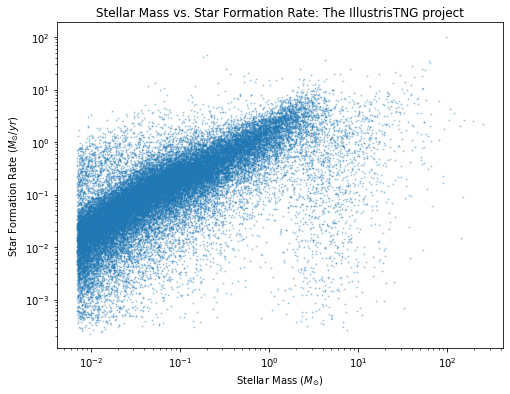

In [14]:
import matplotlib.pyplot as plt
import numpy as np

stellar_mass = tng_data['mass_stars']
sfr = tng_data['sfr']
plt.figure(figsize=(8, 6))
plt.scatter(stellar_mass, sfr, s=1, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass ($M_{\odot}$)')
plt.ylabel('Star Formation Rate ($M_{\odot}/yr$)')
plt.title('Stellar Mass vs. Star Formation Rate: The IllustrisTNG project')
plt.savefig('tng_sfr_vs_mass.pdf', format='pdf', bbox_inches='tight')
plt.show()

*Do you see any differences between this plot and the same one made using the EAGLE data? What do you think is causing these differences? Specifically consider these plots in the context of the ‘red and dead’ galaxies you read about.*

There are major differences between this plot and the ones made using the EAGLE data as the Main Sequence is more dense in the middle of the sequence with high scattering compared to the EAGLE plot. This may be attributed to the lower stellar masses, as the stellar masses range mostly from 10^-2 to 10^2 whereas the EAGLE stellar masses range from 10^6 to 10^12. Beyond the units, the physical behavior of the "red and dead" galaxies look different. In EAGLE, there is a distinct empty gap right below the main sequence, showing that the galaxies quench and stop forming stars very rapidly. In TNG, that space has a dense, continuous cloud of transitioning galaxies, implying quenching is a much more gradual process in this simulation. Finally, at the high-mass end, TNG’s main sequence bends downward and scatters much more aggressively than EAGLE's. This might be due to how it models the Active Galactic Nuclei (AGN) feedback (as mentioned in previous sections). 